In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
bias_type = "none"
bias_strength = "0.0"
dataset = "gbs_allensbach"
method = "fw-mrs-temperature"
fixed_hyperparameter = "0.01"

In [4]:
overlapping_allensbach_columns = [
        "Age",
        "Occupational Group",
        "Employment Status",
        "Sex",
        "Optimism",
        "Pessimism",
        "School Degree",
        "Weekly Working Hours",
        "Resilience",
    ]

In [5]:
feature_importances = []

method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
feature_importances/feature_importances.json")
with open(method_path) as file:
    method_feature_importance = np.array(json.load(file))

In [6]:
feature_importances = []
for i in range(len(method_feature_importance)):
    feature_importances.append(method_feature_importance[i]["0.0"][fixed_hyperparameter])

In [7]:
feature_importances_df = pd.DataFrame(feature_importances)
feature_importances_df.columns = overlapping_allensbach_columns
order = feature_importances_df.mean().sort_values(ascending=False).index

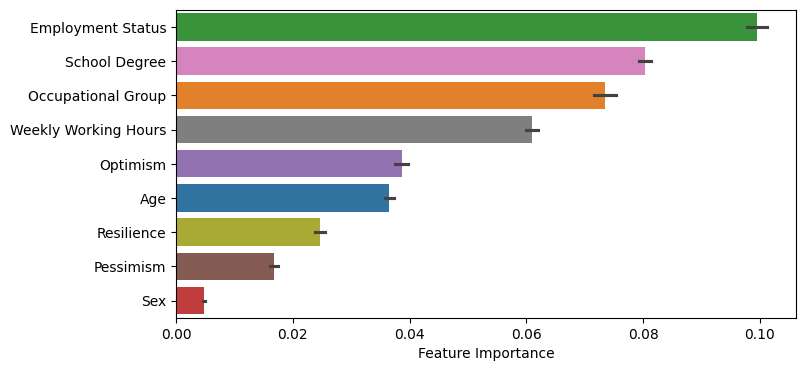

In [15]:
from matplotlib import rcParams

# figure size in inches
rcParams['figure.figsize'] = 8,4

ax = sns.barplot(feature_importances_df, orient="y", order=order)
ax.set(xlabel="Feature Importance")
ax.get_figure().savefig("gbs_allensbach_feature_importances.pdf", bbox_inches='tight') 